In [1]:

import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.options.mode.copy_on_write = True


## Configuration

In [2]:
RETS_CSV = "sp500_returns_with_tickers.csv"  
CAPS_CSV = "sp500_market_caps.csv"          

WINDOW = 36
DATA_FREQ = "M"


OUT_DIR = Path("/mnt/data")
OUT_DIR.mkdir(parents=True, exist_ok=True)
BETAS_OUT    = OUT_DIR / f"betas_w{WINDOW}.parquet"
WEIGHTS_OUT  = OUT_DIR / f"weights_eabc_w{WINDOW}.parquet"
RETURNS_OUT  = OUT_DIR / f"portfolio_returns_w{WINDOW}.parquet"

## Load CSVs and convert to Parquet for faster subsequent runs

In [3]:

def _read_csv(path):
    return pd.read_csv(path, index_col=0, parse_dates=True)

rets = _read_csv(RETS_CSV)
caps = _read_csv(CAPS_CSV)

# Downcast memory
rets = rets.astype("float32")
caps = caps.astype("float32")

# Save Parquet for speed next time
rets.to_parquet(RETS_CSV.replace(".csv", ".parquet"), compression="zstd")
caps.to_parquet(CAPS_CSV.replace(".csv", ".parquet"), compression="zstd")

print("Loaded:", rets.shape, caps.shape)


Loaded: (780, 1863) (780, 1863)


## Align indexes and optionally resample to monthly

In [4]:
# Align intersection of dates and tickers
common_index = rets.index.intersection(caps.index)
common_cols  = rets.columns.intersection(caps.columns)
rets = rets.loc[common_index, common_cols].sort_index()
caps = caps.loc[common_index, common_cols].sort_index()

if DATA_FREQ is not None:
    # Returns should be compounded within period
    compound = lambda df: (1.0 + df).prod() - 1.0
    rets = rets.resample(DATA_FREQ).apply(compound)
    # For caps, use period-end levels (last value)
    caps = caps.resample(DATA_FREQ).last()

print("After resample/alignment:", rets.shape, caps.shape)

C:\Users\Username\AppData\Local\Temp\ipykernel_27000\933873597.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  rets = rets.resample(DATA_FREQ).apply(compound)


After resample/alignment: (780, 1863) (780, 1863)


C:\Users\Username\AppData\Local\Temp\ipykernel_27000\933873597.py:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  caps = caps.resample(DATA_FREQ).last()


## Derive cap weights and market return (`ret_cap`)

In [5]:
# Cap weights per date (normalize row-wise)
cap_weights = caps.div(caps.sum(axis=1), axis=0).fillna(0.0)

# Market (cap-weighted) return
ret_cap = (rets * cap_weights).sum(axis=1).astype("float32")
ret_cap.name = "ret_cap"

print("ret_cap:", ret_cap.shape, "nan%", ret_cap.isna().mean()*100)

ret_cap: (780,) nan% 0.0


## Vectorized rolling beta vs. cap-weighted market

In [6]:
def rolling_beta_matrix(rets_df: pd.DataFrame, market_ret: pd.Series, window: int) -> pd.DataFrame:
    mean_R = rets_df.rolling(window, min_periods=window).mean()
    mean_M = market_ret.rolling(window, min_periods=window).mean()

    EXY   = (rets_df.mul(market_ret, axis=0)).rolling(window, min_periods=window).mean()
    covRM = EXY - mean_R.mul(mean_M, axis=0)

    EM2   = (market_ret.pow(2)).rolling(window, min_periods=window).mean()
    varM  = EM2 - mean_M.pow(2)

    betas = covRM.div(varM, axis=0)
    return betas

t0 = time.time()
betas = rolling_beta_matrix(rets, ret_cap, WINDOW).astype("float32")
t1 = time.time()
print(f"Betas computed in {t1 - t0:.2f}s ; shape={betas.shape}")
betas.to_parquet(BETAS_OUT, compression="zstd")

Betas computed in 0.38s ; shape=(780, 1863)


## Closed-form Equal-Absolute-Beta-Contribution (EABC) weights

In [7]:
# === Use provided EBC weights (optimization-based), not 1/beta ===
import pandas as pd

w_eabc = pd.read_csv("ebc_weights.csv", index_col=0, parse_dates=True).astype("float32")

common_idx  = w_eabc.index.intersection(rets.index)
common_cols = w_eabc.columns.intersection(rets.columns)
w_eabc = w_eabc.loc[common_idx, common_cols]

print("EBC weights (from csv) shape:", w_eabc.shape)


EBC weights (from csv) shape: (696, 1596)


## Portfolio returns: EABC and Cap-Weighted

In [8]:

cap_w_lag  = cap_weights.shift(1)
cap_w_lag  = cap_w_lag.div(cap_w_lag.sum(axis=1), axis=0).fillna(0.0)

eabc_w_lag = w_eabc.shift(1)  

port_eabc = pd.read_csv("equal_beta_portfolio_return.csv", parse_dates=[0])
if port_eabc.shape[1] == 2:
    port_eabc.columns = ["date", "ret"]

port_eabc["date"] = pd.to_datetime(port_eabc["date"], errors="coerce")
port_eabc = port_eabc.dropna(subset=["date"])
port_eabc["date"] = port_eabc["date"].dt.to_period("M").dt.to_timestamp("M")

port_eabc = port_eabc.set_index("date")["ret"].astype("float32")
port_eabc = port_eabc.reindex(rets.index).dropna()

port_eabc.name = "EBC_external"
print("EBC return (from csv) length:", len(port_eabc))
print("sample indices:", port_eabc.index[:3], "vs", rets.index[:3])

valid_mask = eabc_w_lag.notna() & (eabc_w_lag != 0.0)
valid_mask = valid_mask.reindex_like(rets).fillna(0.0).astype("float32")

cap_w_same = (cap_w_lag * valid_mask)
cap_w_same = cap_w_same.div(cap_w_same.sum(axis=1), axis=0).fillna(0.0)

cap_port_same = (rets * cap_w_same).sum(axis=1).astype("float32")
cap_port_same.name = "CW"

ew_w = rets.notna().astype("float32")
ew_w = ew_w.div(ew_w.sum(axis=1), axis=0).fillna(0.0).shift(1)
ew_w_same = (ew_w * valid_mask)
ew_w_same = ew_w_same.div(ew_w_same.sum(axis=1), axis=0).fillna(0.0)

ew_port_same = (rets * ew_w_same).sum(axis=1).astype("float32")
ew_port_same.name = "EW"

cap_port_full  = (rets * cap_w_lag).sum(axis=1).astype("float32")
cap_port_full.name = "CW_full"

cw_ebc_same = (cap_port_same - port_eabc).rename("CW-EBC")
cw_ew_same  = (cap_port_same - ew_port_same).rename("CW-EW")

cw_ebc_full = (cap_port_full - port_eabc).rename("CW-EBC_fullUniverse")

portfolio_returns = pd.DataFrame({
    "CW": cap_port_same,
    "CW-EBC": cw_ebc_same,
    "CW-EW": cw_ew_same,
    f"EBC_{WINDOW}": port_eabc,
    "CW_full": cap_port_full,
    "CW-EBC_fullUniverse": cw_ebc_full
}).dropna()

portfolio_returns.to_parquet(RETURNS_OUT, compression="zstd")
portfolio_returns.tail()


EBC return (from csv) length: 696
sample indices: DatetimeIndex(['1967-01-31', '1967-02-28', '1967-03-31'], dtype='datetime64[ns]', name='date', freq='ME') vs DatetimeIndex(['1960-01-31', '1960-02-29', '1960-03-31'], dtype='datetime64[ns]', name='date', freq='ME')


,CW,CW-EBC,CW-EW,EBC_36,CW_full,CW-EBC_fullUniverse
date,,,,,,
2024-08-31,0.023659,-0.006543,-0.000470,0.030202,0.024283,-0.005919
2024-09-30,0.021491,0.005238,0.001524,0.016253,0.022573,0.006320
2024-10-31,-0.009386,0.007510,0.007111,-0.016896,-0.008689,0.008207
2024-11-30,0.058121,0.003936,0.001188,0.054184,0.060234,0.006050
2024-12-31,-0.021601,0.041833,0.040098,-0.063435,-0.023401,0.040033


## Quick plots

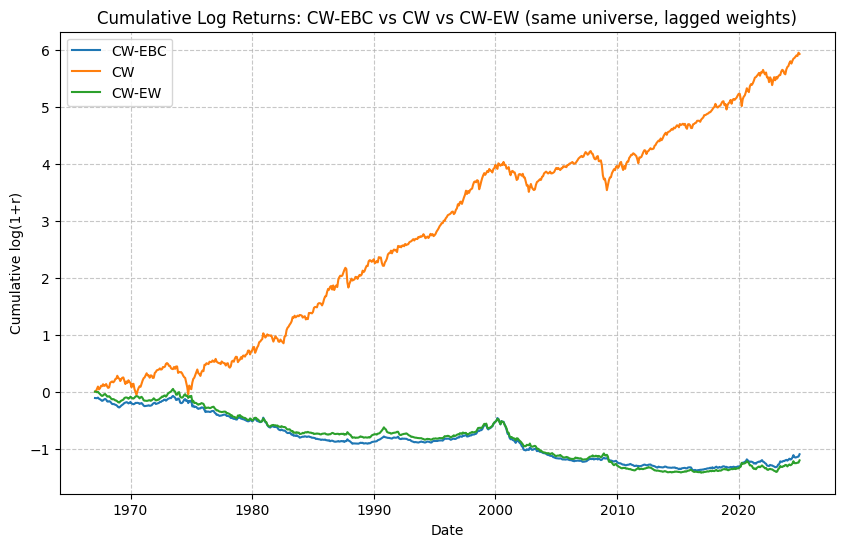

In [9]:
import numpy as np
import matplotlib.pyplot as plt

df = portfolio_returns[["CW-EBC", "CW", "CW-EW"]].dropna().sort_index()
cum = np.log1p(df).cumsum()

plt.figure(figsize=(10,6))
for col in cum.columns:
    plt.plot(cum.index, cum[col], label=col)
plt.title("Cumulative Log Returns: CW-EBC vs CW vs CW-EW (same universe, lagged weights)")
plt.xlabel("Date")
plt.ylabel("Cumulative log(1+r)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

In [10]:
ff5 = pd.read_csv(r"C:\Users\Username\OneDrive\Desktop\Invesco_project\F-F_Research_Data_5_Factors_2x3.csv", skiprows =3, nrows =742)
ff5.rename(columns={"Unnamed: 0": "Date"}, inplace=True)
ff5["Date"] = pd.to_datetime(ff5["Date"], format="%Y%m")
ff5.set_index("Date", inplace=True)
ff5 = ff5.astype(float) / 100

ffm = pd.read_csv(r"C:\Users\Username\OneDrive\Desktop\Invesco_project\F-F_Momentum_Factor.csv",skiprows= 13, nrows = 1180)
ffm.rename(columns={"Unnamed: 0": "Date"}, inplace=True)
ffm["Date"] = pd.to_datetime(ffm["Date"], format="%Y%m")
ffm.set_index("Date", inplace=True)
ffm = ffm.astype(float) / 100

ff = ff5.join(ffm, how="inner")
ff

,Mkt-RF,SMB,HML,RMW,CMA,RF,Mom
Date,,,,,,,
1963-07-01,-0.0039,-0.0048,-0.0081,0.0064,-0.0115,0.0027,0.0101
1963-08-01,0.0508,-0.0080,0.0170,0.0040,-0.0038,0.0025,0.0100
1963-09-01,-0.0157,-0.0043,0.0000,-0.0078,0.0015,0.0027,0.0012
1963-10-01,0.0254,-0.0134,-0.0004,0.0279,-0.0225,0.0029,0.0313
1963-11-01,-0.0086,-0.0085,0.0173,-0.0043,0.0227,0.0027,-0.0078
...,...,...,...,...,...,...,...
2024-12-01,-0.0315,-0.0384,-0.0300,0.0191,-0.0121,0.0037,-0.0030
2025-01-01,0.0280,-0.0122,0.0162,-0.0233,-0.0324,0.0037,0.0095
2025-02-01,-0.0243,-0.0493,0.0491,0.0109,0.0306,0.0033,-0.0082


In [11]:
ff_p = ff.copy()
ff_p.index = ff_p.index.to_period("M")  

pref = portfolio_returns[["CW-EBC", "CW-EW", "CW"]].copy()
pref_p = pref.copy()
pref_p.index = pref_p.index.to_period("M")

idx_p = pref_p.index.intersection(ff_p.index)
pref_p = pref_p.loc[idx_p].astype(float)
ff_p   = ff_p.loc[idx_p].astype(float)

print("Aligned (PeriodIndex) span:", idx_p.min(), "→", idx_p.max(), "| rows:", len(idx_p))

pref_m = pref_p.copy()
ff_m   = ff_p.copy()
pref_m.index = pref_m.index.to_timestamp(how="end")
ff_m.index   = ff_m.index.to_timestamp(how="end")

Aligned (PeriodIndex) span: 1967-01 → 2024-12 | rows: 696


In [12]:
df_aligned = pd.concat(
    [
        pref_m[["CW-EBC", "CW-EW"]],
        ff_m[["SMB", "HML", "RMW", "CMA", "Mom"]],
    ],
    axis=1,
).dropna()

desc = df_aligned[["CW-EBC", "CW-EW"]].describe().T[["mean", "std", "min", "max"]]
desc["Sharpe_annual"] = desc["mean"] / desc["std"] * np.sqrt(12)
display(desc)

print("Corrs:")
corrs = df_aligned.corr().loc[
    ["CW-EBC", "CW-EW"], [ "SMB", "HML", "RMW", "CMA", "Mom"]
]
display(corrs)

,mean,std,min,max,Sharpe_annual
CW-EBC,-0.001447,0.016047,-0.105809,0.059936,-0.312297
CW-EW,-0.001589,0.016748,-0.098411,0.069971,-0.328759


Corrs:


,SMB,HML,RMW,CMA,Mom
CW-EBC,-0.445886,-0.488298,-0.038721,-0.361549,0.282164
CW-EW,-0.591757,-0.430804,0.075205,-0.256817,0.405303


In [13]:
import statsmodels.api as sm

X = sm.add_constant(df_aligned[[ "SMB", "HML", "RMW", "CMA", "Mom"]])
for fac in ["CW-EBC", "CW-EW"]:
    y = df_aligned[fac]
    m = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 6})
    print("="*24, fac, "="*24)
    print(m.summary())
    print("Annualized alpha:", float(m.params["const"]) * 12, "\n")

======================== CW-EBC ========================
                            OLS Regression Results                            
Dep. Variable:                 CW-EBC   R-squared:                       0.505
Model:                            OLS   Adj. R-squared:                  0.501
Method:                 Least Squares   F-statistic:                     43.14
Date:                Tue, 23 Sep 2025   Prob (F-statistic):           9.94e-39
Time:                        07:10:12   Log-Likelihood:                 2133.7
No. Observations:                 696   AIC:                            -4255.
Df Residuals:                     690   BIC:                            -4228.
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------

In [14]:
import numpy as np
import pandas as pd

def to_month_end(s):
    out = s.copy()
    out.index = pd.PeriodIndex(out.index, freq="M").to_timestamp(how="end")
    return out

def clean_numeric(x):
    if isinstance(x, pd.Series):
        x = pd.to_numeric(x, errors="coerce")
        return x.replace([np.inf, -np.inf], np.nan).astype("float64")
    else:
        x = x.apply(pd.to_numeric, errors="coerce")
        return x.replace([np.inf, -np.inf], np.nan).astype("float64")

rets        = to_month_end(rets)
pref_series = to_month_end(pref_m["CW-EBC"])    
# mkt_series  = to_month_end(ff_m["Mkt-RF"])

rets        = clean_numeric(rets)
pref_series = clean_numeric(pref_series)
# mkt_series  = clean_numeric(mkt_series)

common_idx  = rets.index.intersection(pref_series.index)
rets        = rets.loc[common_idx]
pref_series = pref_series.loc[common_idx]
# mkt_series  = mkt_series.loc[common_idx]

print("Aligned span:", rets.index.min(), "→", rets.index.max(), " | months:", len(rets))


Aligned span: 1967-01-31 23:59:59.999999999 → 2024-12-31 23:59:59.999999999  | months: 696


In [15]:
import statsmodels.api as sm

def nw_mean_t(series: pd.Series, lags: int = 6):
    y = pd.to_numeric(pd.Series(series), errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
    if len(y) == 0:
        return np.nan, np.nan, np.nan
    y_arr = y.to_numpy(dtype="float64")
    X_arr = np.ones((len(y_arr), 1), dtype="float64")
    res = sm.OLS(y_arr, X_arr).fit(cov_type="HAC", cov_kwds={"maxlags": lags})
    mean = float(res.params[0]); se = float(res.bse[0])
    tval = mean / se if se > 0 else np.nan
    return mean, se, tval


def rolling_beta_single_factor(returns_df: pd.DataFrame, factor: pd.Series, window: int = 36) -> pd.DataFrame:
    R = returns_df.astype("float32"); f = factor.astype("float32")
    mean_R = R.rolling(window, min_periods=window).mean()
    mean_f = f.rolling(window, min_periods=window).mean()
    EXY    = (R.mul(f, axis=0)).rolling(window, min_periods=window).mean()
    covRf  = EXY - mean_R.mul(mean_f, axis=0)
    Ef2    = (f.pow(2)).rolling(window, min_periods=window).mean()
    var_f  = Ef2 - mean_f.pow(2)
    return covRf.div(var_f, axis=0)

def fama_macbeth(rets: pd.DataFrame,
                 pref_series: pd.Series,
                 mkt_series: pd.Series | None = None,
                 window: int = 36,
                 nw_lags: int = 6,
                 min_stocks: int = 50,
                 verbose: bool = True):

    idx = rets.index
    if mkt_series is not None:
        idx = idx.intersection(mkt_series.index)
    idx = idx.intersection(pref_series.index)
    R      = rets.loc[idx].astype("float64")
    f_pref = pref_series.loc[idx].astype("float64")
    f_mkt  = mkt_series.loc[idx].astype("float64") if mkt_series is not None else None

    beta_pref = rolling_beta_single_factor(R, f_pref, window=window).shift(1)
    beta_mkt  = rolling_beta_single_factor(R, f_mkt,  window=window).shift(1) if f_mkt is not None else None

    valid_mask = beta_pref.notna().any(axis=1)
    dates_all  = beta_pref.index[valid_mask].to_list()
    if len(dates_all) < 2:
        raise ValueError("No usable data.")

    lambdas, lambdas_mkt, r2_cs, Ns = [], [], [], []
    kept_months = skipped_smallN = skipped_allNaN = 0

    for i in range(len(dates_all) - 1):
        t  = dates_all[i]
        t1 = dates_all[i + 1]

        X = pd.DataFrame({"beta_pref": beta_pref.loc[t]})
        if beta_mkt is not None:
            X["beta_mkt"] = beta_mkt.loc[t]
        y_next = R.loc[t1]  

        df = X.join(y_next.rename("ret_next")).replace([np.inf, -np.inf], np.nan).dropna()
        if df.empty:
            skipped_allNaN += 1; continue
        if len(df) < min_stocks:
            skipped_smallN += 1; continue

        feats = ["beta_pref"] + (["beta_mkt"] if beta_mkt is not None else [])
        X_arr = sm.add_constant(df[feats].astype("float64").to_numpy())
        y_arr = df["ret_next"].astype("float64").to_numpy()
        mdl = sm.OLS(y_arr, X_arr).fit()

        lambdas.append(mdl.params[1])                
        if beta_mkt is not None:
            lambdas_mkt.append(mdl.params[2])         
        r2_cs.append(mdl.rsquared); Ns.append(len(df))
        kept_months += 1

    if verbose:
        print(f"[FM] kept months={kept_months}, skipped_smallN={skipped_smallN}, skipped_allNaN={skipped_allNaN}")

    out = {}
    if kept_months == 0:
        out["lambda_pref_mean"] = out["lambda_pref_t"] = out["mean_crosssec_R2"] = out["mean_N"] = np.nan
        return out

    lam_s = pd.Series(lambdas, index=[d for d in dates_all[1:1+len(lambdas)]])
    mean_lam, se_lam, t_lam = nw_mean_t(lam_s, lags=nw_lags)
    out["lambda_pref_mean"] = mean_lam
    out["lambda_pref_t"]    = t_lam
    out["lambda_pref_se"]   = se_lam

    if mkt_series is not None and len(lambdas_mkt) > 0:
        lam_mkt_s = pd.Series(lambdas_mkt, index=lam_s.index[:len(lambdas_mkt)])
        mean_lm, se_lm, t_lmkt = nw_mean_t(lam_mkt_s, lags=nw_lags)
        out["lambda_mkt_mean"] = mean_lm
        out["lambda_mkt_t"]    = t_lmkt
        out["lambda_mkt_se"]   = se_lm

    out["mean_crosssec_R2"] = float(np.nanmean(r2_cs)) if r2_cs else np.nan
    out["mean_N"]           = float(np.nanmean(Ns))    if Ns else np.nan
    out["lambda_series"]    = lam_s
    return out

In [16]:
for pref_name in ["CW-EBC", "CW-EW"]:
    fm_out = fama_macbeth(rets=rets,
                          pref_series=pref_m[pref_name],
                          mkt_series=None,
                          window=36, nw_lags=6,
                          min_stocks=50, verbose=False)
    print(f"[FM] {pref_name}  mean λ={fm_out.get('lambda_pref_mean')},  t={fm_out.get('lambda_pref_t')},  "
          f"mean CS R²={fm_out.get('mean_crosssec_R2')},  mean N={fm_out.get('mean_N')}")


[FM] CW-EBC  mean λ=-0.0018796933776779774,  t=-3.076390594031952,  mean CS R²=0.060395178398622414,  mean N=1863.0
[FM] CW-EW  mean λ=-0.002808486432759728,  t=-4.429266056956438,  mean CS R²=0.09185228830847547,  mean N=1863.0


In [17]:
fac_names = ["SMB","HML","RMW","CMA","Mom"]
beta_ctrl = {}
for nm in fac_names:
    beta_ctrl[nm] = rolling_beta_single_factor(rets, ff_m[nm], window=36).shift(1)

def fama_macbeth_with_controls(rets, beta_pref, beta_ctrl_dict, min_stocks=50, nw_lags=6):
    dates = beta_pref.index[beta_pref.notna().any(axis=1)].to_list()
    lam_pref, lam_ctrl, Ns, R2 = [], {k: [] for k in beta_ctrl_dict}, [], []
    import statsmodels.api as sm
    for i in range(len(dates)-1):
        t, t1 = dates[i], dates[i+1]
        X = pd.DataFrame({"beta_pref": beta_pref.loc[t]})
        for k, B in beta_ctrl_dict.items():
            X[k] = B.loc[t]
        y = rets.loc[t1]  
        df = X.join(y.rename("ret_next")).replace([np.inf,-np.inf], np.nan).dropna()
        if len(df) < min_stocks: continue
        cols = ["beta_pref"] + fac_names
        Xarr = sm.add_constant(df[cols].astype("float64").to_numpy())
        yarr = df["ret_next"].astype("float64").to_numpy()
        mdl = sm.OLS(yarr, Xarr).fit()
        lam_pref.append(mdl.params[1])
        for j,k in enumerate(fac_names, start=2):
            lam_ctrl[k].append(mdl.params[j])
        R2.append(mdl.rsquared); Ns.append(len(df))
    
    def nw(s):
        y = pd.Series(s).dropna()
        if len(y)==0: return np.nan, np.nan
        res = sm.OLS(y, np.ones((len(y),1))).fit(cov_type="HAC", cov_kwds={"maxlags": nw_lags})
        return float(res.params[0]), float(res.tvalues[0])
    out = {"lambda_pref": nw(lam_pref), "mean_R2": float(np.nanmean(R2)), "mean_N": float(np.nanmean(Ns))}
    out["lambda_ctrl"] = {k: nw(v) for k,v in lam_ctrl.items()}
    return out

beta_pref = rolling_beta_single_factor(rets, pref_m["CW-EBC"], window=36).shift(1)
res_ctrl = fama_macbeth_with_controls(rets, beta_pref, beta_ctrl)
print("λ_pref mean,t =", res_ctrl["lambda_pref"], " | mean R²:", res_ctrl["mean_R2"], " | mean N:", res_ctrl["mean_N"])
print("controls (mean,t):", res_ctrl["lambda_ctrl"])


λ_pref mean,t = (-0.0012955802879200911, -1.6365268373923696)  | mean R²: 0.1743445636861039  | mean N: 1863.0
controls (mean,t): {'SMB': (-0.0013317066004979148, -0.9653030083623827), 'HML': (-0.0023030473955271647, -1.476906709669712), 'RMW': (-0.0010236198030543703, -0.8000289119449498), 'CMA': (-0.0011897340742000589, -1.310814578705048), 'Mom': (3.3580629875242445e-07, 0.00024054058928937622)}


C:\Users\Username\AppData\Local\Temp\ipykernel_27000\3140366755.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return float(res.params[0]), float(res.tvalues[0])
C:\Users\Username\AppData\Local\Temp\ipykernel_27000\3140366755.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return float(res.params[0]), float(res.tvalues[0])
C:\Users\Username\AppData\Local\Temp\ipykernel_27000\3140366755.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `

In [18]:
import pandas as pd


W = 36         
min_stocks = 50
nw_lags = 6
pref_list = ["CW-EBC", "CW-EW"]          
fac_names = ["SMB","HML","RMW","CMA","Mom"]  


beta_ctrl = {
    nm: rolling_beta_single_factor(rets, ff_m[nm], window=W).shift(1)
    for nm in fac_names
}


rows = []
for pref_name in pref_list:
    beta_pref = rolling_beta_single_factor(rets, pref_m[pref_name], window=W).shift(1)
    res = fama_macbeth_with_controls(
        rets=rets,
        beta_pref=beta_pref,
        beta_ctrl_dict=beta_ctrl,
        min_stocks=min_stocks,
        nw_lags=nw_lags
    )
    row = {
        "factor": pref_name,
        "lambda_pref_mean": res["lambda_pref"][0],
        "t_lambda_pref":    res["lambda_pref"][1],
        "mean_R2":          res["mean_R2"],
        "mean_N":           res["mean_N"],
    }
   
    for k, (m, t) in res["lambda_ctrl"].items():
        row[f"{k}_mean"] = m
        row[f"{k}_t"]    = t
    rows.append(row)

res_table = pd.DataFrame(rows)

order_cols = (
    ["factor","lambda_pref_mean","t_lambda_pref","mean_R2","mean_N"] +
    sum([[f"{k}_mean", f"{k}_t"] for k in fac_names], [])
)
res_table = res_table[order_cols]

display(res_table)


C:\Users\Username\AppData\Local\Temp\ipykernel_27000\3140366755.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return float(res.params[0]), float(res.tvalues[0])
C:\Users\Username\AppData\Local\Temp\ipykernel_27000\3140366755.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return float(res.params[0]), float(res.tvalues[0])
C:\Users\Username\AppData\Local\Temp\ipykernel_27000\3140366755.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `

,factor,lambda_pref_mean,t_lambda_pref,mean_R2,mean_N,SMB_mean,SMB_t,HML_mean,HML_t,RMW_mean,RMW_t,CMA_mean,CMA_t,Mom_mean,Mom_t
0,CW-EBC,-0.001296,-1.636527,0.174345,1863.0,-0.001332,-0.965303,-0.002303,-1.476907,-0.001024,-0.800029,-0.001190,-1.310815,3.358063e-07,0.000241
1,CW-EW,-0.002401,-2.133498,0.176319,1863.0,-0.002717,-1.913990,-0.001625,-1.065967,-0.000960,-0.793374,-0.001305,-1.498793,1.786003e-03,0.982891


In [19]:
print("CW-EBC:")
for W in [24, 36, 60]:
    fm_out = fama_macbeth(rets, pref_m["CW-EBC"], None, window=W, min_stocks=50, verbose=False)
    print(f"W={W}: λ={fm_out.get('lambda_pref_mean')}, t={fm_out.get('lambda_pref_t')}")

print("CW-EW:")
for W in [24, 36, 60]:
    fm_out = fama_macbeth(rets, pref_m["CW-EW"], None, window=W, min_stocks=50, verbose=False)
    print(f"W={W}: λ={fm_out.get('lambda_pref_mean')}, t={fm_out.get('lambda_pref_t')}")


CW-EBC:
W=24: λ=-0.0015474052385350179, t=-2.807855902314144
W=36: λ=-0.0018796933776779774, t=-3.076390594031952
W=60: λ=-0.00228962894442434, t=-3.3716952825371953
CW-EW:
W=24: λ=-0.0023250879809636827, t=-3.986774550157857
W=36: λ=-0.002808486432759728, t=-4.429266056956438
W=60: λ=-0.0030932835820620787, t=-4.5979107984942145


In [20]:
import os
import pandas as pd

CACHE_DIR = "cache"

def _load_parquet(name):
    path = os.path.join(CACHE_DIR, f"{name}.parquet")
    return pd.read_parquet(path)

def _col0(obj, name_if_series=None):
    if isinstance(obj, pd.DataFrame):
        s = obj.iloc[:, 0].copy()
        if name_if_series:
            s.name = name_if_series
        return s
    if isinstance(obj, pd.Series):
        if name_if_series:
            obj = obj.copy()
            obj.name = name_if_series
        return obj
    raise TypeError("Expect Series or single-column DataFrame")

def to_month_start(idx):
    idx = pd.to_datetime(idx)
    mend = idx.to_period("M").to_timestamp("M")
    return mend - pd.offsets.MonthEnd(1) + pd.offsets.MonthBegin(1)


cap_ret = _col0(_load_parquet("ret_cap"), "CW")                     
ew_ret  = _col0(_load_parquet("ret_eq"), "EW")                      
ebc_ret = _col0(_load_parquet("preference_returns"), "EBC")         
ff      = _load_parquet("ffm_clean")                                


for s in (cap_ret, ew_ret, ebc_ret):
    s.index = to_month_start(s.index)
    s.sort_index(inplace=True)
ff.index = to_month_start(ff.index)
ff.sort_index(inplace=True)


cw_ew  = (cap_ret - ew_ret).rename("CW_EW")      # CW − EW
cw_ebc = (cap_ret - ebc_ret).rename("CW_EBC")    # CW − EBC

panel = pd.concat([cw_ew, cw_ebc, ff], axis=1).dropna()

needed = ["CW_EW","CW_EBC","Mkt-RF","SMB","HML","RMW","CMA","Mom","RF"]
missing = [c for c in needed if c not in panel.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}. Got: {panel.columns.tolist()}")

panel.head()


,CW_EW,CW_EBC,Mkt-RF,SMB,HML,RMW,CMA,RF,Mom
1963-07-01,0.010777,-0.011361,-0.0039,-0.0048,-0.0081,0.0064,-0.0115,0.0027,0.0101
1963-08-01,-0.003005,0.057987,0.0508,-0.0080,0.0170,0.0040,-0.0038,0.0025,0.0100
1963-09-01,0.010682,-0.019518,-0.0157,-0.0043,0.0000,-0.0078,0.0015,0.0027,0.0012
1963-10-01,0.012468,0.026247,0.0254,-0.0134,-0.0004,0.0279,-0.0225,0.0029,0.0313
1963-11-01,0.001468,-0.004267,-0.0086,-0.0085,0.0173,-0.0043,0.0227,0.0027,-0.0078


In [21]:
# -------- Cell N: FF6 regressions (OLS + HAC) and tidy outputs --------
import numpy as np
import statsmodels.api as sm

def ff6_reg(df, yname, maxlags=6):
    y_ex = df[yname]
    X = sm.add_constant(df[["SMB","HML","RMW","CMA","Mom"]])
    model = sm.OLS(y_ex, X).fit(cov_type="HAC", cov_kwds={"maxlags": maxlags})
    return model

def pack_row(name, model):
    p, t = model.params, model.tvalues
    alpha_m = p["const"]
    alpha_ann = (1.0 + alpha_m)**12 - 1.0
    return {
        "strategy": name,
        "alpha_ann_%": alpha_ann * 100.0,
        "t_alpha(NW)": t["const"],
        "beta_SMB": p["SMB"],   "t_SMB": t["SMB"],
        "beta_HML": p["HML"],   "t_HML": t["HML"],
        "beta_RMW": p["RMW"],   "t_RMW": t["RMW"],
        "beta_CMA": p["CMA"],   "t_CMA": t["CMA"],
        "beta_Mom": p["Mom"],   "t_Mom": t["Mom"],
        "R2": model.rsquared, "Obs": int(model.nobs)
    }

def print_summary_no_datetime(title, model):
    txt = model.summary().as_text()
    lines = []
    for ln in txt.splitlines():
        if ln.strip().startswith("Date:") or ln.strip().startswith("Time:"):
            continue
        lines.append(ln)
    print("="*86)
    print(title)
    print("="*86)
    print("\n".join(lines))
    print()

res_ew  = ff6_reg(panel, "CW_EW",  maxlags=6)
res_ebc = ff6_reg(panel, "CW_EBC", maxlags=6)

print_summary_no_datetime("FF6 Regression: CW − EW",  res_ew)
print_summary_no_datetime("FF6 Regression: CW − EBC", res_ebc)

summary_df = pd.DataFrame([pack_row("CW−EW", res_ew),
                           pack_row("CW−EBC", res_ebc)]).set_index("strategy")
display(summary_df.round(3))

summary_path = os.path.join("cache", "ff6_summary_cw_ew_ebc.parquet")
summary_df.to_parquet(summary_path)
print("Saved:", summary_path)


FF6 Regression: CW − EW
                            OLS Regression Results                            
Dep. Variable:                  CW_EW   R-squared:                       0.614
Model:                            OLS   Adj. R-squared:                  0.612
Method:                 Least Squares   F-statistic:                     125.6
No. Observations:                 738   AIC:                            -4623.
Df Residuals:                     732   BIC:                            -4595.
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0036      0.000      8.152      0.000       0.003       0.004
SMB           -0.3501      0.027    -12.905      0.000      -0.403      -0.297
HML           -0.1597      0

,alpha_ann_%,t_alpha(NW),beta_SMB,t_SMB,beta_HML,t_HML,beta_RMW,t_RMW,beta_CMA,t_CMA,beta_Mom,t_Mom,R2,Obs
strategy,,,,,,,,,,,,,,
CW−EW,4.393,8.152,-0.35,-12.905,-0.160,-5.231,-0.090,-1.662,-0.025,-0.707,0.127,5.238,0.614,738
CW−EBC,17.213,8.250,0.48,5.241,0.204,1.667,-0.075,-0.600,-0.696,-4.396,-0.299,-4.688,0.245,738


Saved: cache\ff6_summary_cw_ew_ebc.parquet



=== Rolling BFM — CW−EW as Pref | WIN=36 ===


,lambda_mean_month,lambda_mean_annual,t_NW
factor,,,
SMB,0.0009,0.0113,1.1142
HML,0.0002,0.0026,0.2622
RMW,-0.0002,-0.0026,-0.3997
CMA,-0.0006,-0.0066,-0.9443
Mom,-0.0011,-0.0137,-0.9765
Pref,-0.0014,-0.0168,-2.4651


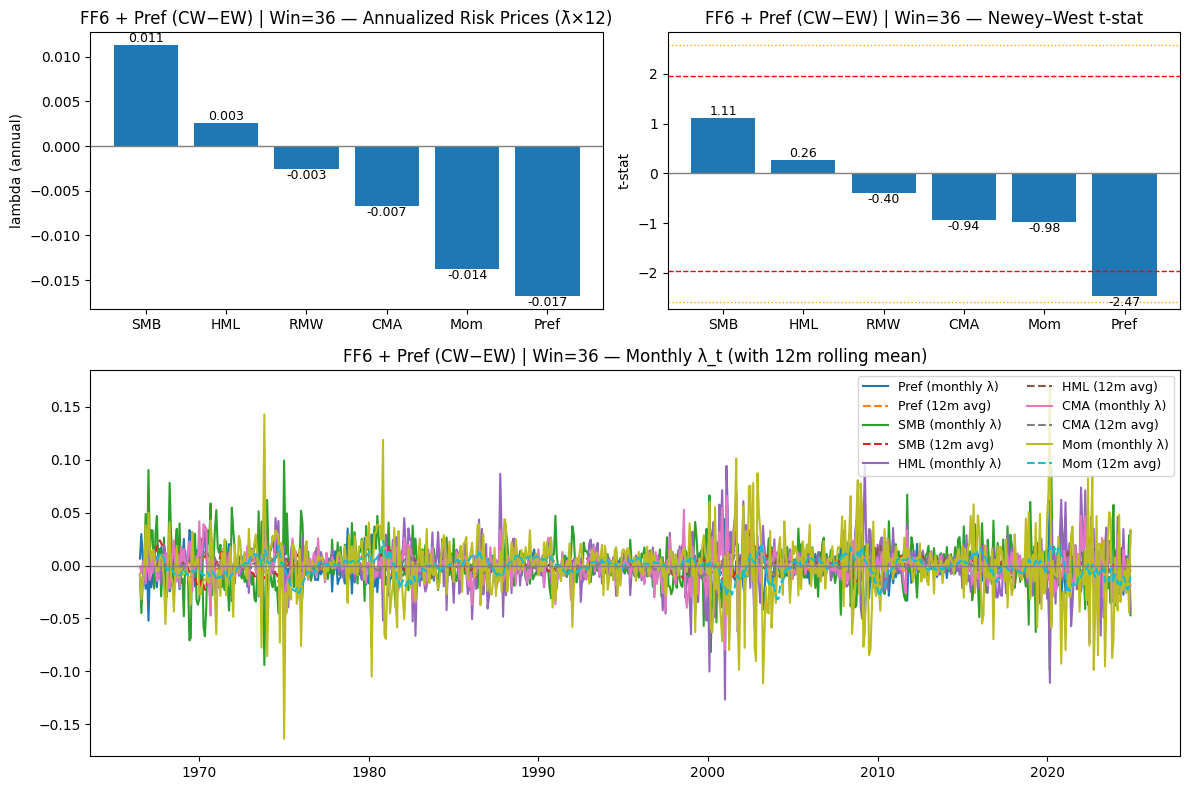

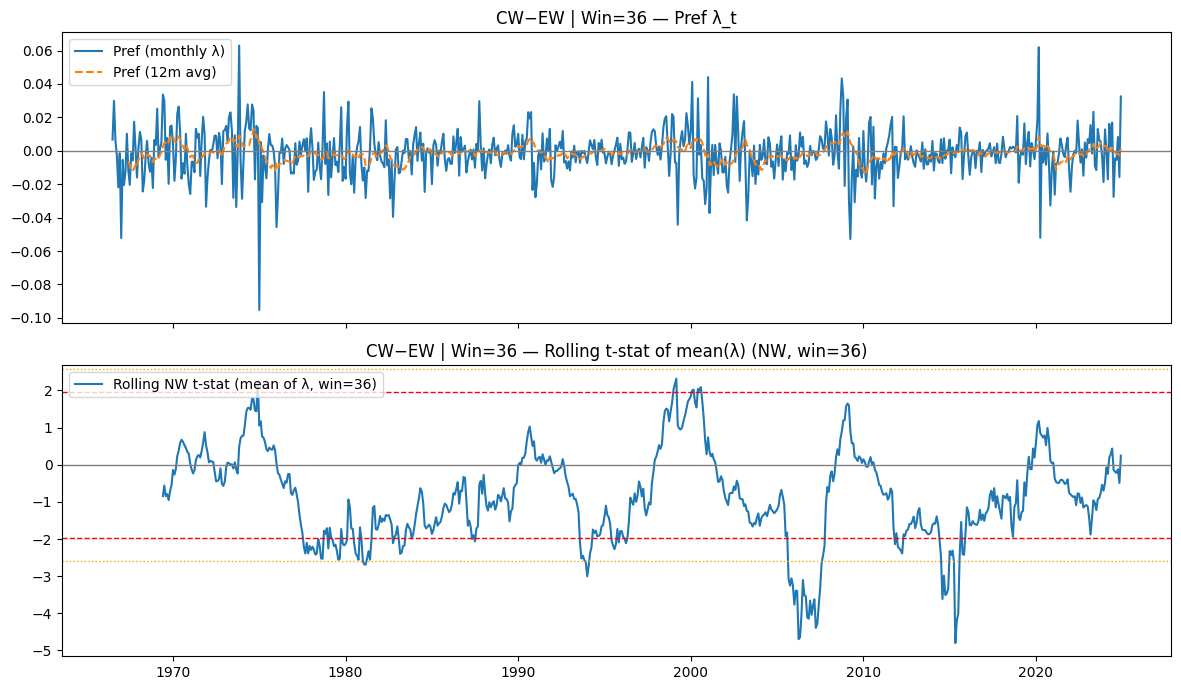


=== Rolling BFM — CW−EBC as Pref | WIN=36 ===


,lambda_mean_month,lambda_mean_annual,t_NW
factor,,,
Pref,0.0062,0.0740,3.6004
HML,0.0005,0.0059,0.6362
SMB,0.0002,0.0027,0.3079
RMW,-0.0000,-0.0002,-0.0310
CMA,-0.0002,-0.0026,-0.3970
Mom,-0.0004,-0.0046,-0.3664


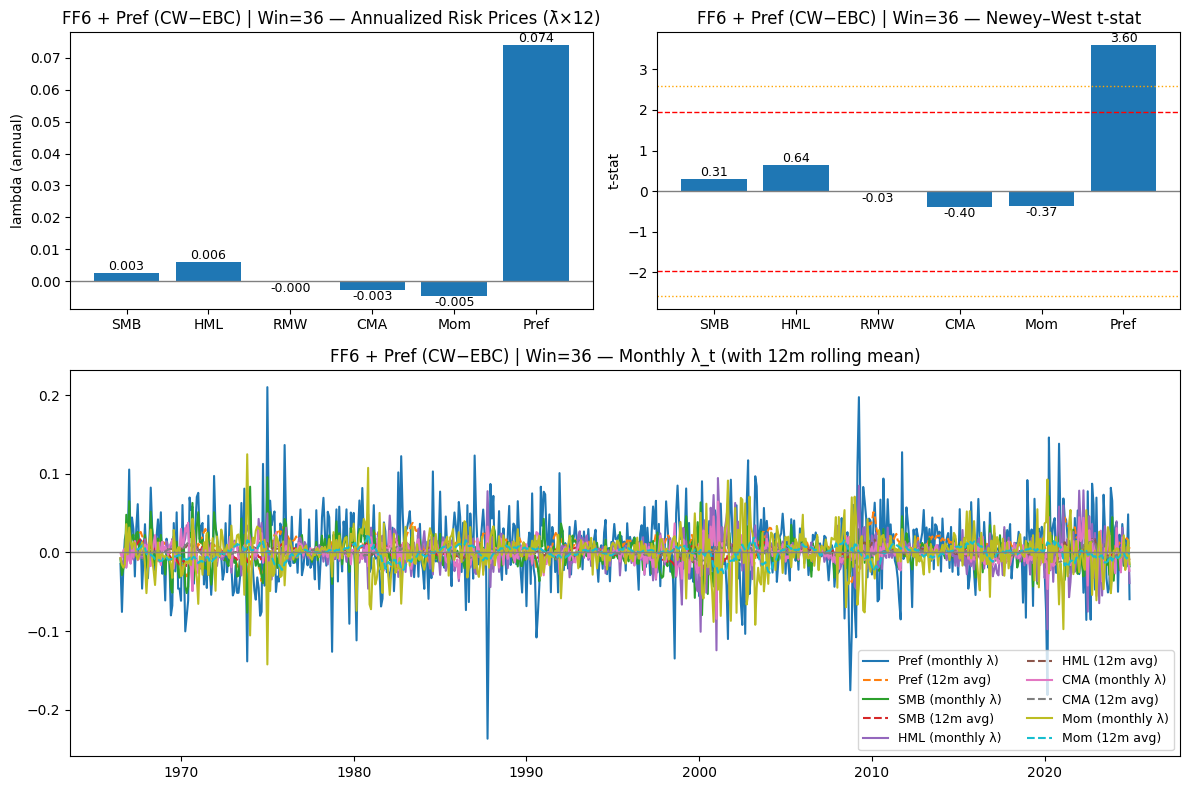

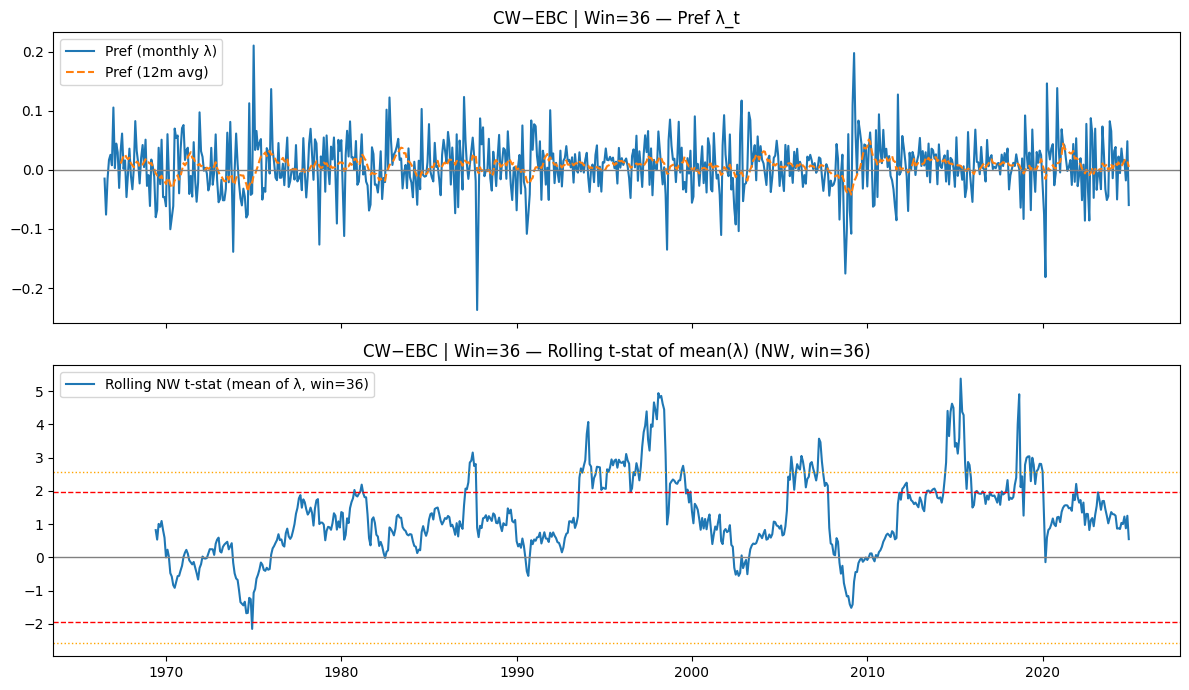

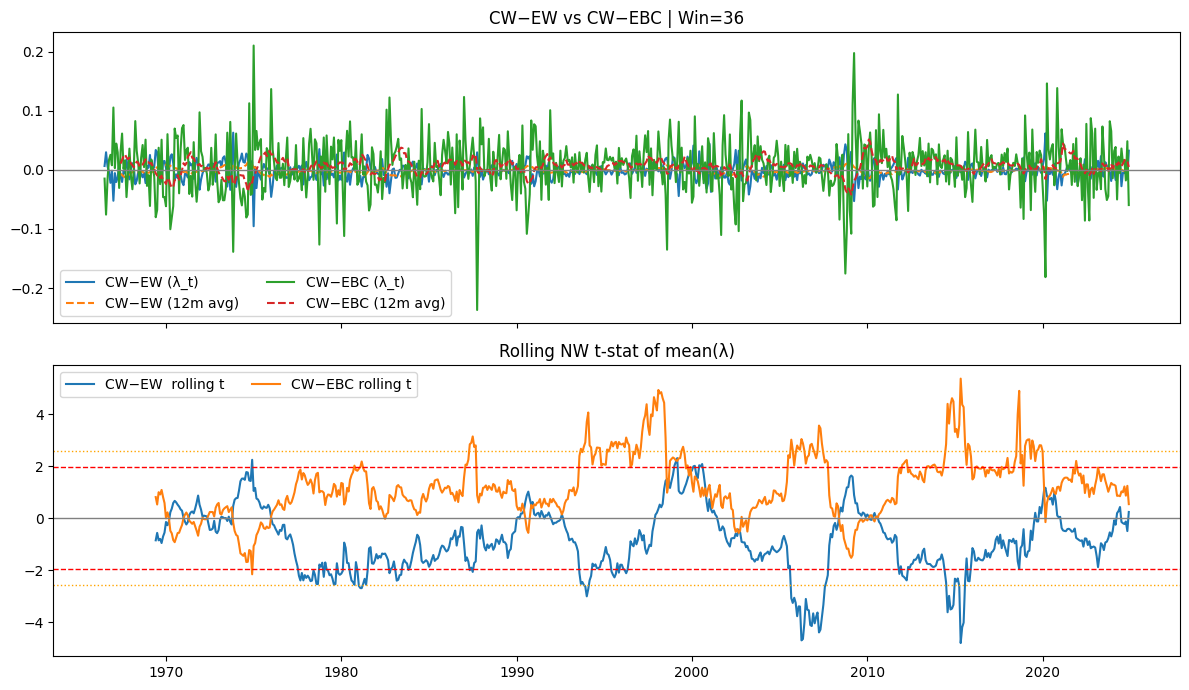

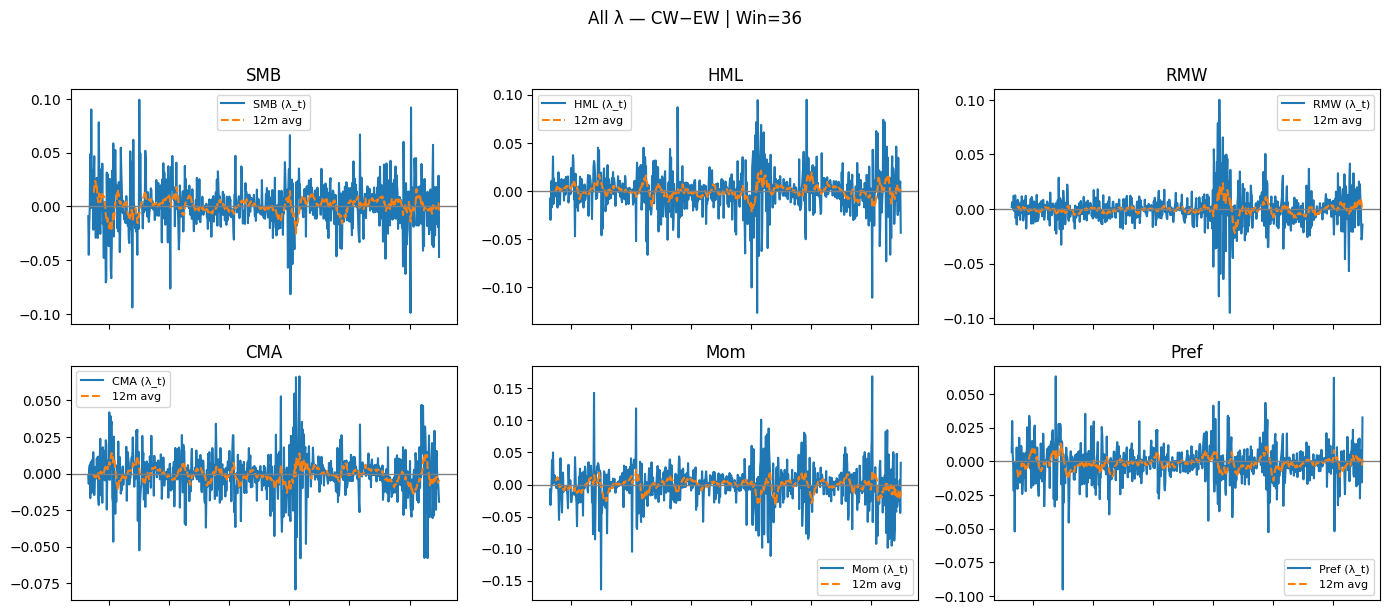

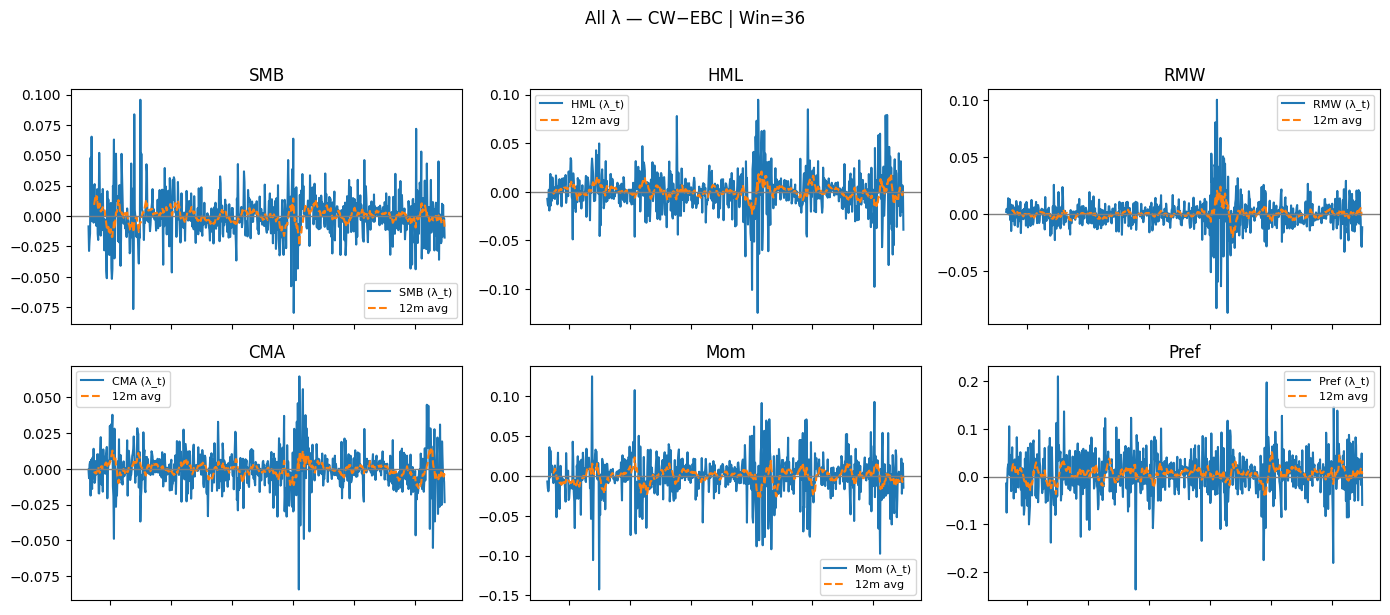

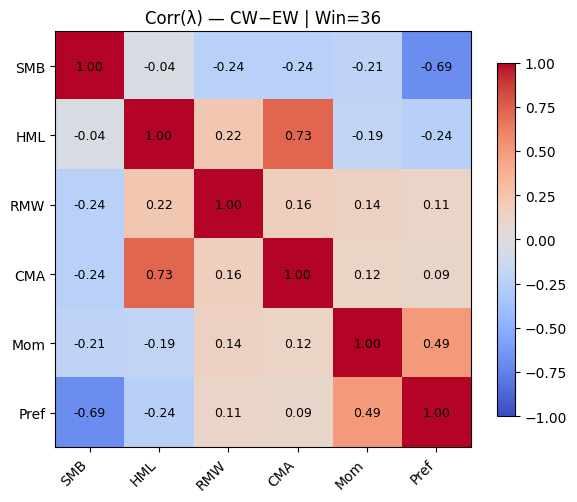

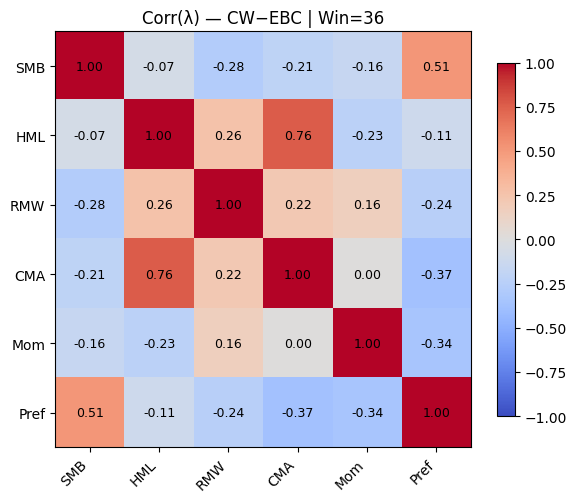


=== Rolling BFM — CW−EW as Pref | WIN=60 ===


,lambda_mean_month,lambda_mean_annual,t_NW
factor,,,
SMB,0.0007,0.0078,0.7582
HML,0.0001,0.0016,0.1410
RMW,-0.0004,-0.0047,-0.6183
CMA,-0.0006,-0.0076,-0.9087
Pref,-0.0014,-0.0173,-2.4621
Mom,-0.0015,-0.0185,-1.2135


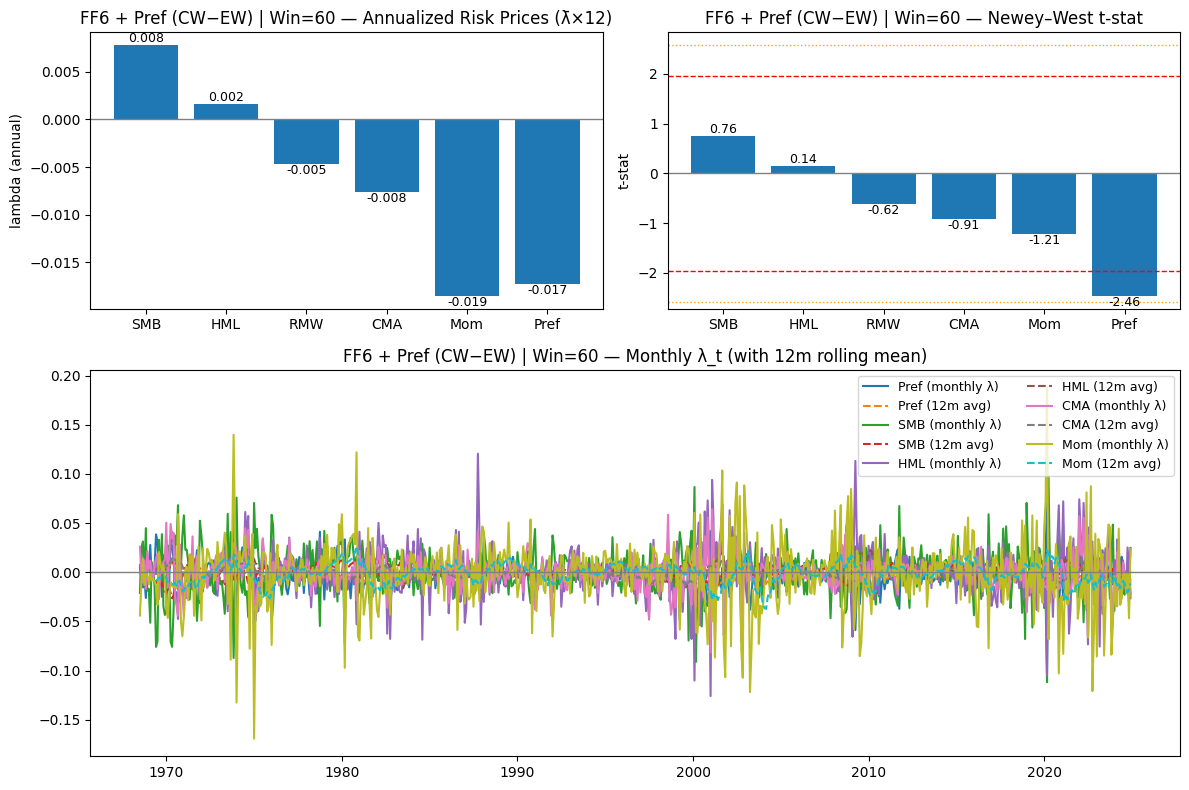

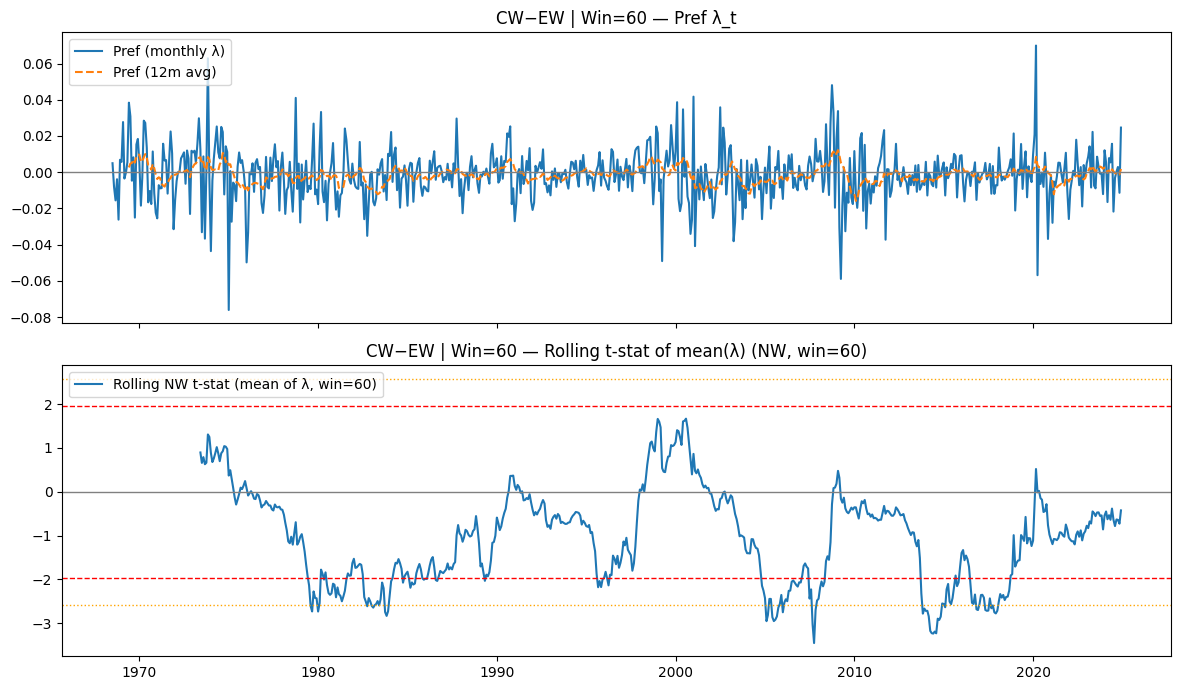


=== Rolling BFM — CW−EBC as Pref | WIN=60 ===


,lambda_mean_month,lambda_mean_annual,t_NW
factor,,,
Pref,0.0060,0.0719,3.3820
HML,0.0007,0.0082,0.7664
SMB,-0.0001,-0.0007,-0.0809
CMA,-0.0001,-0.0010,-0.1288
RMW,-0.0002,-0.0028,-0.4073
Mom,-0.0005,-0.0062,-0.4522


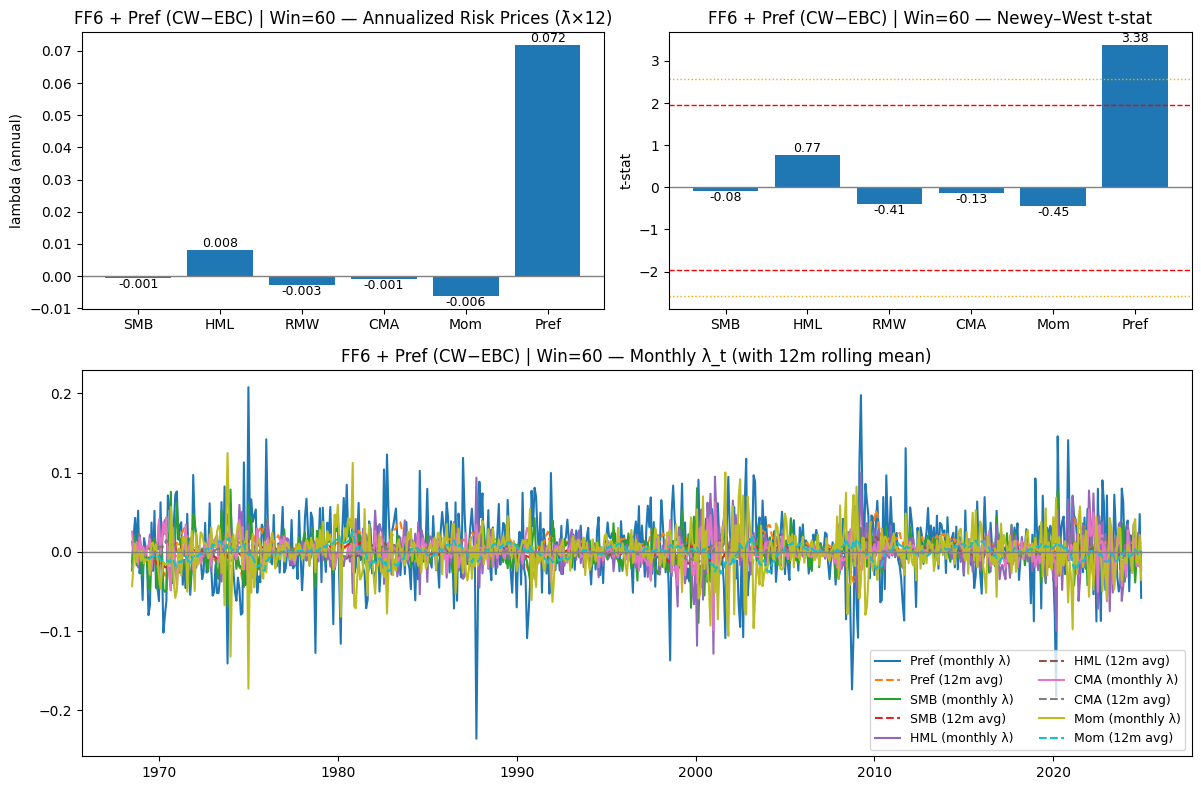

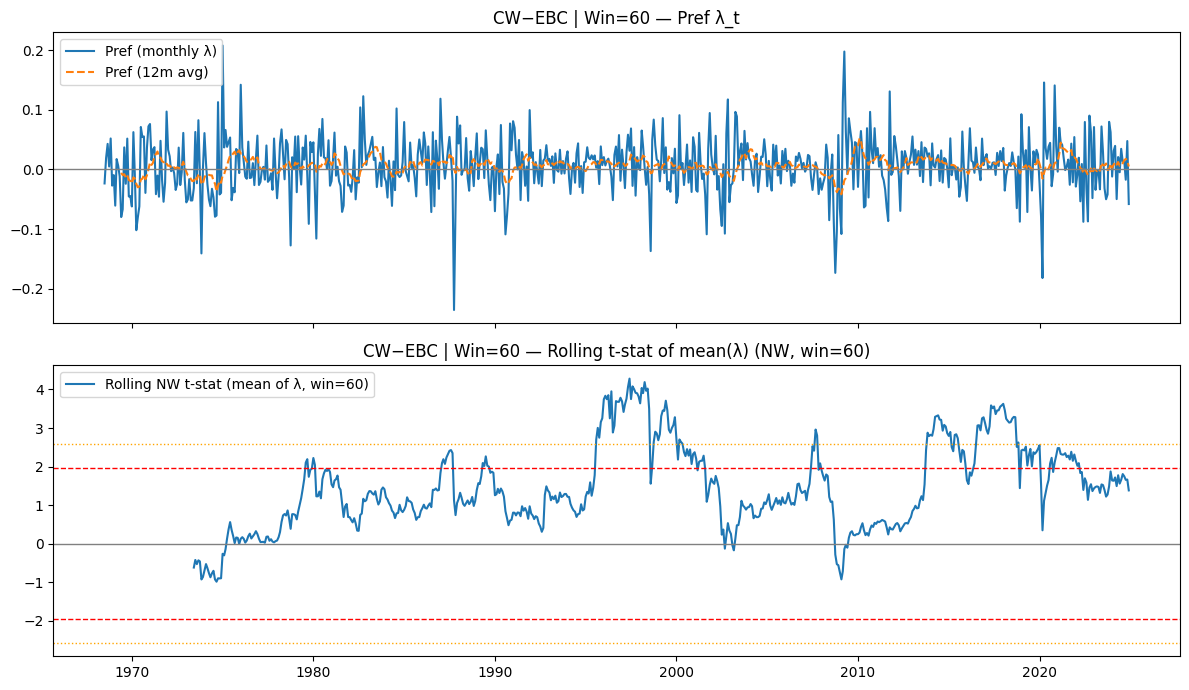

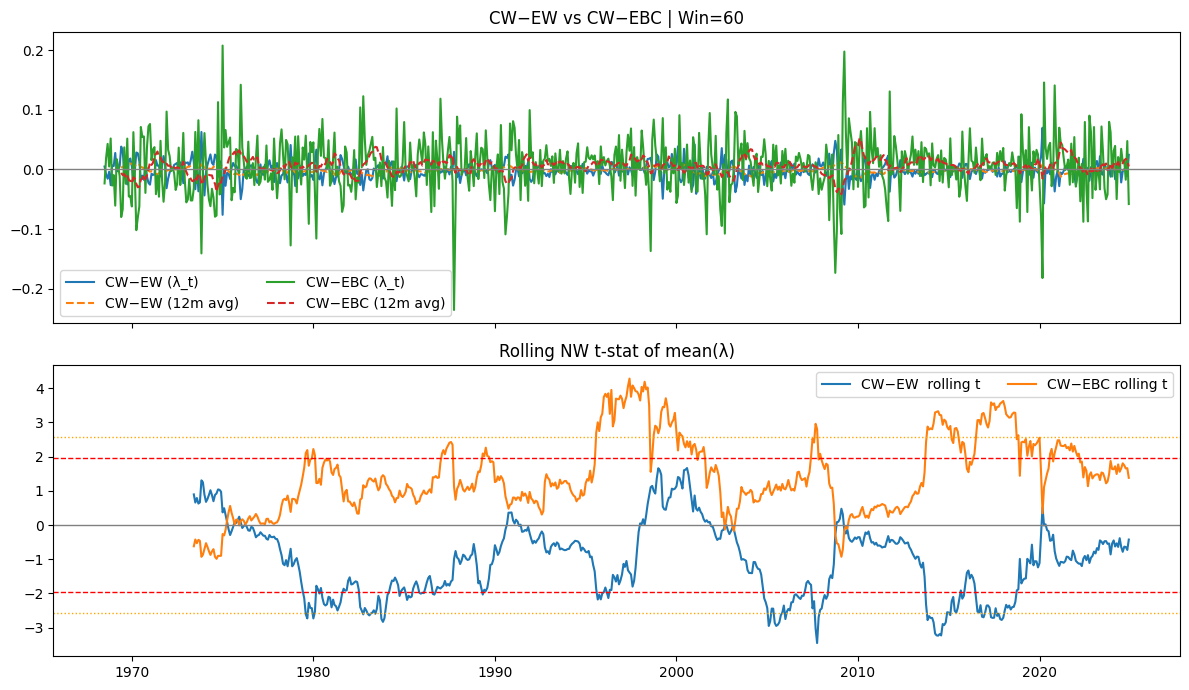

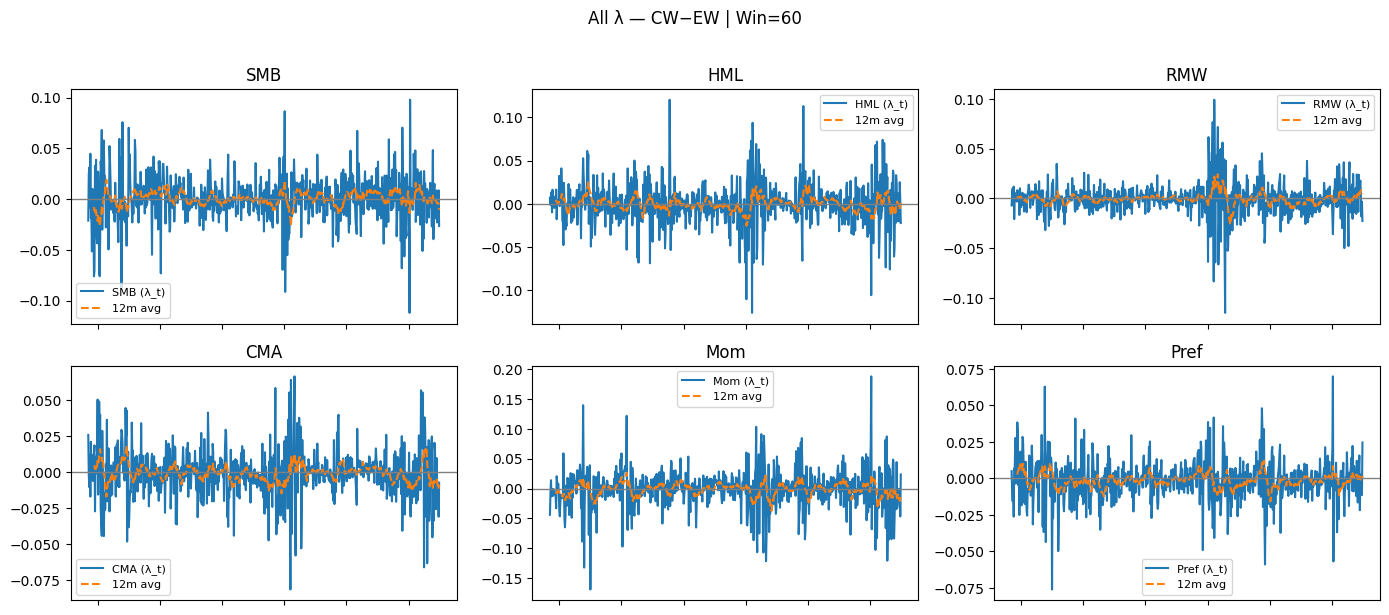

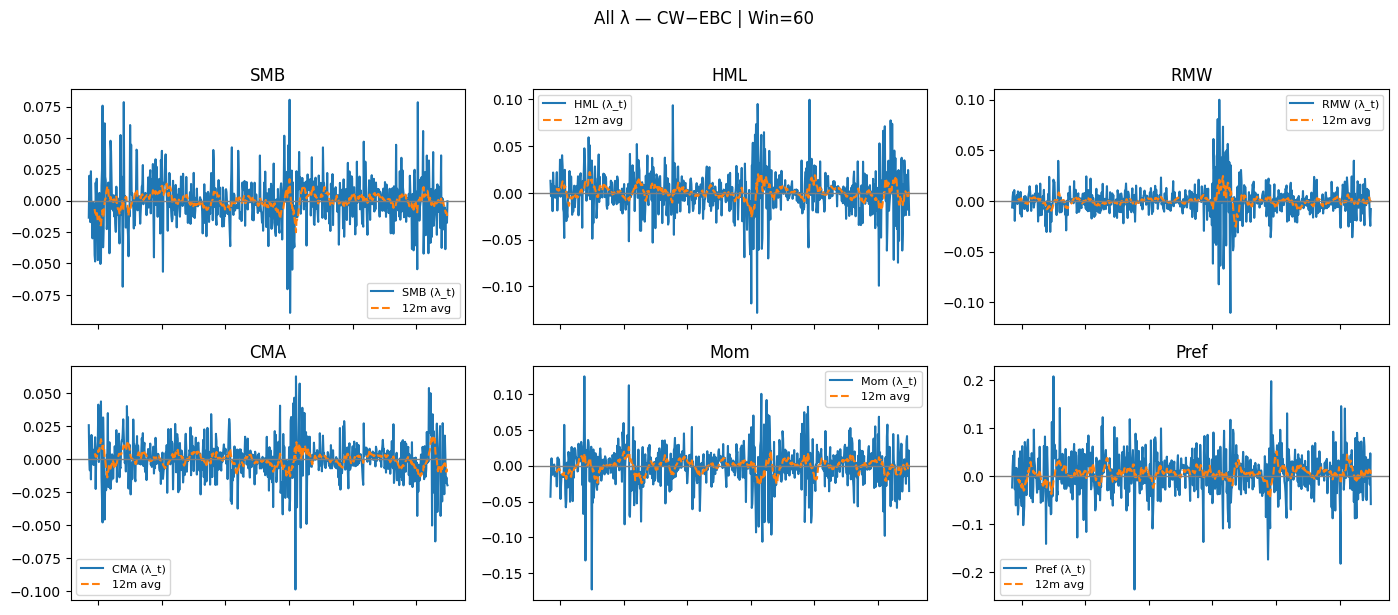

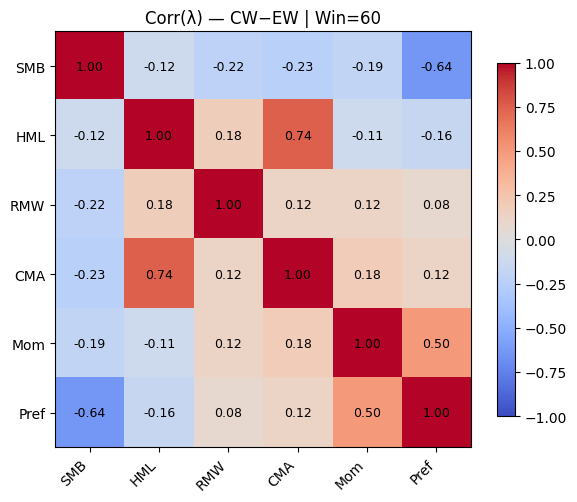

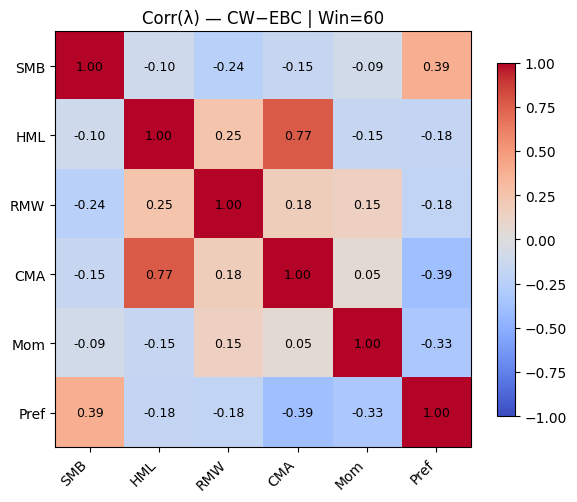


=== Pref risk price comparison across windows (rolling) ===


,lambda_mean_month,lambda_mean_annual,t_NW
CW−EW | 36m,-0.0014,-0.0168,-2.4651
CW−EBC | 36m,0.0062,0.0740,3.6004
CW−EW | 60m,-0.0014,-0.0173,-2.4621
CW−EBC | 60m,0.0060,0.0719,3.3820


In [22]:
import os
import re
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# ---------------- User inputs (edit here) ----------------
WINDOW       = 36     
RIDGE_ALPHA  = 1.0    
NW_MAXLAGS   = 6      # Newey–West lag
ORTHO_PREF   = False  
CACHE_DIR    = "cache"

# ------------------- IO helpers -------------------
def _load(name):
    p = os.path.join(CACHE_DIR, f"{name}.parquet")
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing: {p}")
    return pd.read_parquet(p)

def _col0(df_or_s, name=None):
    if isinstance(df_or_s, pd.DataFrame):
        s = df_or_s.iloc[:, 0].copy()
        if name: s.name = name
        return s
    s = df_or_s.copy()
    if name: s.name = name
    return s

def to_mstart(idx):
    idx = pd.to_datetime(idx)
    mend = idx.to_period("M").to_timestamp("M")
    return mend - pd.offsets.MonthEnd(1) + pd.offsets.MonthBegin(1)

def nw_mean_t(series, maxlags=6):
    y = series.dropna()
    if len(y) < 12:
        return np.nan, np.nan
    X = np.ones((len(y), 1))
    res = sm.OLS(y.values, X).fit(cov_type="HAC", cov_kwds={"maxlags": maxlags})
    return float(res.params[0]), float(res.tvalues[0])

# ----------- Label normalization for plotting -----------
ALIAS = {
    "SMB"   : ["smb","size"],
    "HML"   : ["hml","value"],
    "RMW"   : ["rmw","profit","robust-minus-weak","profitability"],
    "CMA"   : ["cma","invest","conservative-minus-aggressive","investment"],
    "Mom"   : ["mom","umd","momentum"],
    "Pref"  : ["pref","preference","cw_ew","cw-ew","cw_ebc","cw-ebc"]
}
STD_ORDER = ["SMB","HML","RMW","CMA","Mom","Pref"]

def _normalize_labels(labels):
    lab_std = []
    for lab in labels:
        s = str(lab).strip()
        s_low = re.sub(r"[^a-z0-9\-]+", "_", s.lower())
        mapped = None
        for std, alist in ALIAS.items():
            if s_low == std.lower() or s_low in alist:
                mapped = std
                break
        lab_std.append(mapped if mapped else s)
    return lab_std

def _coerce_index_to_std(obj):
    if isinstance(obj, pd.DataFrame):
        obj = obj.copy()
        if obj.index.dtype == "O":
            obj.index = _normalize_labels(obj.index)
        obj.columns = _normalize_labels(obj.columns)
        return obj
    elif isinstance(obj, pd.Series):
        s = obj.copy()
        s.index = _normalize_labels(s.index)
        return s
    else:
        return obj

def _ensure_order_series(s, order):
    s = _coerce_index_to_std(s)
    keep = [k for k in order if k in s.index]
    if not keep:
        raise KeyError(f"No requested factors found. Available: {list(s.index)}")
    return s.loc[keep]

def _ensure_order_df_cols(df, order):
    df = _coerce_index_to_std(df)
    keep = [k for k in order if k in df.columns]
    if not keep:
        raise KeyError(f"No requested factors found. Available columns: {list(df.columns)}")
    return df[keep]

# ------------------- Rolling BFM core -------------------
def run_bfm_rolling(rets, ffm, pref_series,
                    window=60, ridge_alpha=1.0, nw_maxlags=6, orthogonalize=False):
    """
    Rolling-window Fama–MacBeth with Ridge (Bayesian shrinkage)
      Stage-1: for each month t, use past `window` months to regress each asset's excess return
               on FF6 + Pref → get betas_t-1
      Stage-2: cross-sectional Ridge regression at month t: r_ex_t = B_t * lambda_t + eps

    Returns:
      summary: factor table with annualized lambda mean & NW t-stat
      Lambda : monthly lambda_t for all 7 factors
    """
    # 1) build factor panel
    F = pd.concat([
        ffm[["SMB","HML","RMW","CMA","Mom"]],
        pref_series.rename("Pref")
    ], axis=1).dropna()

    R  = rets.reindex(F.index).dropna(how="all", axis=1)   # T×N
    F  = F.loc[R.index]
    RF = ffm["RF"].reindex(R.index)

    # Optional orthogonalization of Pref vs FF6
    if orthogonalize:
        Xb = sm.add_constant(F[["SMB","HML","RMW","CMA","Mom"]])
        fit = sm.OLS(F["Pref"], Xb).fit()
        F["Pref"] = F["Pref"] - fit.predict(Xb)

    colsX = ["SMB","HML","RMW","CMA","Mom","Pref"]
    T = len(F)
    idx = F.index

    lambdas = []
    dates   = []

    # 2) rolling stage-1 & stage-2
    for t in range(window, T):
        end_month   = idx[t]          
        win_slice   = idx[t-window:t] 
        F_win       = F.loc[win_slice, colsX]
        X_win       = sm.add_constant(F_win)

        r_win = (R.loc[win_slice] - RF.loc[win_slice].values.reshape(-1,1))
        r_t   = (R.loc[end_month]  - RF.loc[end_month])  

        betas_t = {}
        for name in R.columns:
            y = r_win[name].dropna()
            if len(y) < max(24, window//2):  
                continue
            X = X_win.loc[y.index]
            try:
                res = sm.OLS(y.values, X.values).fit()
                b = pd.Series(res.params, index=X.columns)
                betas_t[name] = b.drop("const")
            except Exception:
                continue

        if not betas_t:
            continue

        B = pd.DataFrame(betas_t).T  
        y_cs = r_t.reindex(B.index).dropna()
        B    = B.loc[y_cs.index]    

        if len(y_cs) < len(colsX) + 5:
            continue

        # Ridge λ_t = (B'B + αI)^(-1) B'y
        BtB  = B.values.T @ B.values
        BtY  = B.values.T @ y_cs.values
        lam  = np.linalg.solve(BtB + ridge_alpha * np.eye(len(colsX)), BtY)
        lambdas.append(lam); dates.append(end_month)

    Lambda = pd.DataFrame(lambdas, index=dates, columns=colsX)

    # 3) time-series inference for lambda (NW)
    rows = []
    for k in Lambda.columns:
        mu, tval = nw_mean_t(Lambda[k], maxlags=nw_maxlags)
        rows.append({"factor": k,
                     "lambda_mean_month": mu,
                     "lambda_mean_annual": mu * 12,
                     "t_NW": tval})
    summary = pd.DataFrame(rows).set_index("factor").sort_values("lambda_mean_month", ascending=False)
    return summary, Lambda

# ------------------- Visualization -------------------
def plot_bfm_all(summary, Lambda, title="FF6 + Pref"):
    summary = _coerce_index_to_std(summary)
    Lambda  = _coerce_index_to_std(Lambda)
    if "lambda_mean_annual" not in summary.columns or "t_NW" not in summary.columns:
        raise KeyError("summary needs ['lambda_mean_annual','t_NW'].")

    s_ann = _ensure_order_series(summary["lambda_mean_annual"], STD_ORDER)
    s_t   = _ensure_order_series(summary["t_NW"],             STD_ORDER)
    L     = _ensure_order_df_cols(Lambda, STD_ORDER)

    fig = plt.figure(figsize=(12, 8))
    gs  = fig.add_gridspec(2, 2, height_ratios=[1,1.4])
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[1, :])

    ax1.bar(s_ann.index, s_ann.values)
    ax1.set_title(f"{title} — Annualized Risk Prices (λ̄×12)")
    ax1.set_ylabel("lambda (annual)")
    ax1.axhline(0, color="gray", lw=1)
    for i, v in enumerate(s_ann.values):
        ax1.text(i, v, f"{v:.3f}", ha="center", va="bottom" if v>=0 else "top", fontsize=9)

    ax2.bar(s_t.index, s_t.values)
    ax2.set_title(f"{title} — Newey–West t-stat")
    ax2.set_ylabel("t-stat")
    ax2.axhline(0, color="gray", lw=1)
    ax2.axhline(1.96, color="red", ls="--", lw=1)
    ax2.axhline(2.58, color="orange", ls=":", lw=1)
    ax2.axhline(-1.96, color="red", ls="--", lw=1)
    ax2.axhline(-2.58, color="orange", ls=":", lw=1)
    for i, v in enumerate(s_t.values):
        ax2.text(i, v, f"{v:.2f}", ha="center", va="bottom" if v>=0 else "top", fontsize=9)

    sel = [c for c in ["Pref","SMB","HML","CMA","Mom"] if c in L.columns]
    for c in sel:
        ax3.plot(L.index, L[c], label=f"{c} (monthly λ)")
        ax3.plot(L.index, L[c].rolling(12).mean(), linestyle="--", label=f"{c} (12m avg)")
    ax3.axhline(0, color="gray", lw=1)
    ax3.set_title(f"{title} — Monthly λ_t (with 12m rolling mean)")
    ax3.legend(ncol=2, fontsize=9)
    fig.tight_layout()
    plt.show()

# ------------------- Load & align data -------------------
rets_numeric       = _load("rets_numeric")                   
ff                 = _load("ffm_clean")                      
ret_cap            = _col0(_load("ret_cap"), "CW")
ret_eq             = _col0(_load("ret_eq"),  "EW")
preference_returns = _col0(_load("preference_returns"), "EBC")

rets = rets_numeric.copy(); rets.index = to_mstart(rets.index); rets.sort_index(inplace=True)
ff_  = ff.copy();            ff_.index  = to_mstart(ff_.index);  ff_.sort_index(inplace=True)
for s in (ret_cap, ret_eq, preference_returns):
    s.index = to_mstart(s.index); s.sort_index(inplace=True)

cw_ew  = (ret_cap - ret_eq).rename("CW_EW")
cw_ebc = (ret_cap - preference_returns).rename("CW_EBC")

# =============== helpers: rolling NW t-stat of mean & plotting =================
def rolling_nw_t_of_mean(series: pd.Series, window: int = 60, maxlags: int = 6,
                         min_frac: float = 0.8) -> pd.Series:
    s = series.dropna()
    out = pd.Series(index=series.index, dtype=float)

    for i in range(window - 1, len(series)):
        win = series.iloc[i - window + 1: i + 1].dropna()
        if len(win) < max(int(window * min_frac), 12):
            out.iloc[i] = np.nan
            continue
        X = np.ones((len(win), 1))
        res = sm.OLS(win.values, X).fit(cov_type="HAC",
                                        cov_kwds={"maxlags": min(maxlags, max(1, len(win) // 4))})
        out.iloc[i] = float(res.tvalues[0])
    return out

def plot_lambda_and_t_series(Lambda: pd.DataFrame, factor: str = "Pref",
                             roll_win: int = 60, nw_maxlags: int = 6, title: str = ""):
    factor = _normalize_labels([factor])[0]
    if factor not in Lambda.columns:
        raise KeyError(f"{factor} not in Lambda columns: {list(Lambda.columns)}")

    lam = Lambda[factor].copy()
    t_rolling = rolling_nw_t_of_mean(lam, window=roll_win, maxlags=nw_maxlags)

    fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    ax[0].plot(lam.index, lam.values, label=f"{factor} (monthly λ)")
    ax[0].plot(lam.index, lam.rolling(12).mean(), "--", label=f"{factor} (12m avg)")
    ax[0].axhline(0, color="gray", lw=1)
    ax[0].set_title(f"{title} — {factor} λ_t")
    ax[0].legend(loc="upper left")

    ax[1].plot(t_rolling.index, t_rolling.values, label=f"Rolling NW t-stat (mean of λ, win={roll_win})")
    ax[1].axhline(0, color="gray", lw=1)
    ax[1].axhline(1.96, color="red", ls="--", lw=1)
    ax[1].axhline(2.58, color="orange", ls=":", lw=1)
    ax[1].axhline(-1.96, color="red", ls="--", lw=1)
    ax[1].axhline(-2.58, color="orange", ls=":", lw=1)
    ax[1].set_title(f"{title} — Rolling t-stat of mean(λ) (NW, win={roll_win})")
    ax[1].legend(loc="upper left")

    fig.tight_layout()
    plt.show()

def plot_pref_compare(Lambda_ew, Lambda_ebc, win, title="Pref λ Comparison"):
    fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    ax[0].plot(Lambda_ew.index, Lambda_ew["Pref"], label=f"CW−EW (λ_t)")
    ax[0].plot(Lambda_ew.index, Lambda_ew["Pref"].rolling(12).mean(), "--", label="CW−EW (12m avg)")
    ax[0].plot(Lambda_ebc.index, Lambda_ebc["Pref"], label=f"CW−EBC (λ_t)")
    ax[0].plot(Lambda_ebc.index, Lambda_ebc["Pref"].rolling(12).mean(), "--", label="CW−EBC (12m avg)")
    ax[0].axhline(0, color="gray", lw=1); ax[0].legend(ncol=2); ax[0].set_title(f"{title} | Win={win}")

    t_ew  = rolling_nw_t_of_mean(Lambda_ew["Pref"],  window=win, maxlags=NW_MAXLAGS)
    t_ebc = rolling_nw_t_of_mean(Lambda_ebc["Pref"], window=win, maxlags=NW_MAXLAGS)
    ax[1].plot(t_ew.index,  t_ew,  label="CW−EW  rolling t")
    ax[1].plot(t_ebc.index, t_ebc, label="CW−EBC rolling t")
    for y,c,ls in [(0,"gray","-"), (1.96,"red","--"), (2.58,"orange",":"), (-1.96,"red","--"), (-2.58,"orange",":")]:
        ax[1].axhline(y, color=c, ls=ls, lw=1)
    ax[1].legend(ncol=2); ax[1].set_title("Rolling NW t-stat of mean(λ)")
    fig.tight_layout(); plt.show()

def plot_all_factors_timeseries(Lambda, title="Monthly λ_t (all factors)"):
    cols = [c for c in STD_ORDER if c in Lambda.columns]
    r, c = 3, 3
    fig, axes = plt.subplots(r, c, figsize=(14, 9), sharex=True)
    axes = axes.ravel()
    for i, name in enumerate(cols):
        ax = axes[i]
        ax.plot(Lambda.index, Lambda[name], label=f"{name} (λ_t)")
        ax.plot(Lambda.index, Lambda[name].rolling(12).mean(), "--", label="12m avg")
        ax.axhline(0, color="gray", lw=1)
        ax.set_title(name); ax.legend(fontsize=8)
    for j in range(len(cols), r*c):
        fig.delaxes(axes[j])
    fig.suptitle(title); fig.tight_layout(rect=[0,0,1,0.97]); plt.show()

    
def plot_lambda_corr_heatmap(Lambda, title="Corr of λ (factors)"):
    import matplotlib.colors as mcolors
    cols = [c for c in STD_ORDER if c in Lambda.columns]
    C = Lambda[cols].corr()
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(C.values, cmap="coolwarm", vmin=-1, vmax=1, interpolation="nearest")
    ax.set_xticks(range(len(cols))); ax.set_yticks(range(len(cols)))
    ax.set_xticklabels(cols, rotation=45, ha="right"); ax.set_yticklabels(cols)
    for i in range(len(cols)):
        for j in range(len(cols)):
            ax.text(j, i, f"{C.iloc[i,j]:.2f}", ha="center", va="center", color="black", fontsize=9)
    fig.colorbar(im, ax=ax, shrink=0.85); ax.set_title(title); fig.tight_layout(); plt.show()


# ========================== run for 36m & 60m both ==========================
WINDOWS = [36, 60]  

cw_ew  = (ret_cap - ret_eq).rename("CW_EW")
cw_ebc = (ret_cap - preference_returns).rename("CW_EBC")

all_pref_rows = [] 

for WIN in WINDOWS:
    # ---- CW−EW as Pref ----
    sum_ew, Lambda_ew = run_bfm_rolling(
        rets=rets, ffm=ff_, pref_series=cw_ew,
        window=WIN, ridge_alpha=RIDGE_ALPHA,
        nw_maxlags=NW_MAXLAGS, orthogonalize=ORTHO_PREF
    )
    print(f"\n=== Rolling BFM — CW−EW as Pref | WIN={WIN} ===")
    display(sum_ew.round(4))
    plot_bfm_all(sum_ew, Lambda_ew, title=f"FF6 + Pref (CW−EW) | Win={WIN}")

    plot_lambda_and_t_series(Lambda_ew, factor="Pref",
                             roll_win=WIN, nw_maxlags=NW_MAXLAGS,
                             title=f"CW−EW | Win={WIN}")

    # ---- CW−EBC as Pref ----
    sum_ebc, Lambda_ebc = run_bfm_rolling(
        rets=rets, ffm=ff_, pref_series=cw_ebc,
        window=WIN, ridge_alpha=RIDGE_ALPHA,
        nw_maxlags=NW_MAXLAGS, orthogonalize=ORTHO_PREF
    )
    print(f"\n=== Rolling BFM — CW−EBC as Pref | WIN={WIN} ===")
    display(sum_ebc.round(4))
    plot_bfm_all(sum_ebc, Lambda_ebc, title=f"FF6 + Pref (CW−EBC) | Win={WIN}")

    plot_lambda_and_t_series(Lambda_ebc, factor="Pref",
                             roll_win=WIN, nw_maxlags=NW_MAXLAGS,
                             title=f"CW−EBC | Win={WIN}")


    pref_row_ew  = sum_ew.loc["Pref"].rename(f"CW−EW | {WIN}m")
    pref_row_ebc = sum_ebc.loc["Pref"].rename(f"CW−EBC | {WIN}m")
    all_pref_rows.extend([pref_row_ew, pref_row_ebc])

    plot_pref_compare(Lambda_ew, Lambda_ebc, win=WIN, title="CW−EW vs CW−EBC")
    
    plot_all_factors_timeseries(Lambda_ew,  title=f"All λ — CW−EW | Win={WIN}")
    plot_all_factors_timeseries(Lambda_ebc, title=f"All λ — CW−EBC | Win={WIN}")

    plot_lambda_corr_heatmap(Lambda_ew,  title=f"Corr(λ) — CW−EW | Win={WIN}")
    plot_lambda_corr_heatmap(Lambda_ebc, title=f"Corr(λ) — CW−EBC | Win={WIN}")

compare_pref = pd.DataFrame(all_pref_rows)[["lambda_mean_month", "lambda_mean_annual", "t_NW"]]
print("\n=== Pref risk price comparison across windows (rolling) ===")
display(compare_pref.round(4))

